# Assignment 3 — G-Eval with Mistral-7B (SummEval + REALSumm + Multilingual)

**Before doing anything:** `Runtime → Change runtime type → T4 GPU`

| Config | MAX_DOCS | N | Multilingual | Est. Time |
|---|---|---|---|---|
| **This notebook** | 2 | 3 | French (fr) | ~55 min |

**Note:** SummEval and its prompts are downloaded automatically from HuggingFace — no Replication folder needed.

Run cells **top to bottom**. Do not edit anything except Cell 4 (config) if needed.

## Cell 0 — Check GPU

In [1]:
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if r.returncode == 0:
    for line in r.stdout.splitlines():
        if 'T4' in line or 'MiB' in line or 'Driver' in line:
            print(line)
    print('GPU OK.')
else:
    print('NO GPU — go to Runtime → Change runtime type → T4 GPU')

| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
GPU OK.


## Cell 1 — Install Dependencies

In [2]:
!pip install -q torch transformers accelerate bitsandbytes \
    datasets scipy prettytable tqdm pandas matplotlib seaborn numpy
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.5 MB/s eta 0:00:00
All packages installed.


## Cell 2 — Upload Zip
A file picker will appear. Select your **`NLP Assignment 03.zip`**.

Your zip only needs the `Assignment3/` folder — SummEval data is downloaded automatically.

In [3]:
import os, zipfile
from google.colab import files

print('Select your NLP Assignment 03.zip ...')
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
print(f'Uploaded: {zip_name}')

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content')
print('Extracted.')

# Find repo root — walk until we find Assignment3/run_assignment3.py
REPO = None
for root, dirs, fls in os.walk('/content'):
    if 'run_assignment3.py' in fls:
        # root is the Assignment3/ folder; go up one level
        REPO = os.path.dirname(root)
        break

if REPO is None:
    raise RuntimeError('Cannot find run_assignment3.py. Make sure your zip includes the Assignment3/ folder.')

os.chdir(REPO)
print(f'Working directory: {REPO}')
print('Contents:', sorted(os.listdir('.')))

Select your NLP Assignment 03.zip ...


Saving NLP Assignment 03.zip to NLP Assignment 03.zip
Uploaded: NLP Assignment 03.zip
Extracted.
Working directory: /content/NLP Assignment 03
Contents: ['.claude', '.venv', 'Assignment3', 'Assignment3_Colab.ipynb']


## Cell 3 — Verify Files

In [4]:
import os

# These are the ONLY files required in your zip.
# SummEval data + prompts are downloaded automatically from HuggingFace.
required = [
    'Assignment3/run_assignment3.py',
    'Assignment3/prompts/realsumm_litepyramid.txt',
]
ok = True
for f in required:
    exists = os.path.exists(f)
    print(f"  {'OK' if exists else 'MISSING'}  {f}")
    if not exists:
        ok = False

# Optional — show if Replication folder is present (not required)
opt = 'Replication/data/summeval.json'
print(f"  {'OK (local)' if os.path.exists(opt) else 'will download from HuggingFace'}  {opt}")

os.makedirs('Assignment3/outputs', exist_ok=True)
print()
if ok:
    print('All required files present. Ready to run.')
else:
    print('STOP — fix missing files then re-run this cell.')

  OK  Assignment3/run_assignment3.py
  OK  Assignment3/prompts/realsumm_litepyramid.txt
  will download from HuggingFace  Replication/data/summeval.json

All required files present. Ready to run.


## Cell 4 — Config
**Multilingual ON (French). Do not change unless needed.**

In [5]:
# ── Config ────────────────────────────────────────────────────────────────────
MODEL_NAME            = 'mistralai/Mistral-7B-Instruct-v0.3'
MAX_DOCS              = 2      # 2 docs × 16 systems = 32 instances per dim
SELF_CONSISTENCY_N    = 3      # average 3 samples (proposed method)
TEMPERATURE           = 0.7
SEED                  = 42
MAX_INPUT_TOKENS      = 4096
MAX_NEW_TOKENS        = 20
USE_DEBIAS_PROMPT     = True   # Extension 3: bias mitigation

# Multilingual ON — French only (Mistral handles French natively)
RUN_MULTILINGUAL_DEMO         = True
PROMPT_LANGUAGE               = 'fr'   # single language: French
RUN_MULTILINGUAL_DATASET_DEMO = True   # ON — adds ~20 min
MULTILINGUAL_DATASET_NAME     = 'mlsum'
MULTILINGUAL_DATASET_LANGS    = 'fr'
MULTILINGUAL_MAX_SAMPLES      = 30

# Time estimate
instances        = MAX_DOCS * 16   # SummEval: 2 docs × 16 systems
rs_instances     = MAX_DOCS * 25   # REALSumm: 2 docs × 25 systems
sec_per_call     = 3.0
# calls per instance: baseline(1) + proposed(N) + debiased(1) + multilingual(1)
calls_per        = 1 + SELF_CONSISTENCY_N + 1 + 1
summeval_sec     = instances    * calls_per * 4 * sec_per_call
realsumm_sec     = rs_instances * calls_per * 1 * sec_per_call
total_est        = int((summeval_sec + realsumm_sec) / 60 + 8)
if RUN_MULTILINGUAL_DATASET_DEMO:
    total_est += 20

print(f'Model          : {MODEL_NAME}')
print(f'Docs / dim     : {MAX_DOCS}  ({instances} SummEval, {rs_instances} REALSumm instances per dim)')
print(f'N (proposed)   : {SELF_CONSISTENCY_N}')
print(f'Debias         : {USE_DEBIAS_PROMPT}')
print(f'Multilingual   : {RUN_MULTILINGUAL_DEMO} (language: {PROMPT_LANGUAGE})')
print(f'Multilingual dataset demo: {RUN_MULTILINGUAL_DATASET_DEMO} ({MULTILINGUAL_DATASET_NAME}:{MULTILINGUAL_DATASET_LANGS})')
print(f'Est. runtime   : ~{total_est} min on T4')
print()
print('SummEval data  : will download from HuggingFace if local file not found')

Model          : mistralai/Mistral-7B-Instruct-v0.3
Docs / dim     : 2  (32 SummEval, 50 REALSumm instances per dim)
N (proposed)   : 3
Debias         : True
Multilingual   : True (language: fr)
Multilingual dataset demo: True (mlsum:fr)
Est. runtime   : ~81 min on T4

SummEval data  : will download from HuggingFace if local file not found


## Cell 5 — Run Experiments
Live output streams below. **Do not interrupt.**

In [6]:
import subprocess, sys

cmd = [
    sys.executable, 'Assignment3/run_assignment3.py',
    '--backend',            'local',
    '--model_name',         MODEL_NAME,
    '--max_docs',           str(MAX_DOCS),
    '--self_consistency_n', str(SELF_CONSISTENCY_N),
    '--temperature',        str(TEMPERATURE),
    '--seed',               str(SEED),
    '--max_input_tokens',   str(MAX_INPUT_TOKENS),
    '--max_new_tokens',     str(MAX_NEW_TOKENS),
    '--prompt_language',    PROMPT_LANGUAGE,
    '--multilingual_dataset_name',        MULTILINGUAL_DATASET_NAME,
    '--multilingual_dataset_languages',   MULTILINGUAL_DATASET_LANGS,
    '--multilingual_dataset_max_samples', str(MULTILINGUAL_MAX_SAMPLES),
]
if USE_DEBIAS_PROMPT:             cmd.append('--use_debias_prompt')
if RUN_MULTILINGUAL_DEMO:         cmd.append('--run_multilingual_demo')
if RUN_MULTILINGUAL_DATASET_DEMO: cmd.append('--run_multilingual_dataset_demo')

print('Command:', ' '.join(cmd[2:]))
print('=' * 60)

proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                        text=True, bufsize=1)
for line in proc.stdout:
    print(line, end='', flush=True)
proc.wait()

print('=' * 60)
print('DONE.' if proc.returncode == 0 else f'ERROR (exit code {proc.returncode})')

Command: --backend local --model_name mistralai/Mistral-7B-Instruct-v0.3 --max_docs 2 --self_consistency_n 3 --temperature 0.7 --seed 42 --max_input_tokens 4096 --max_new_tokens 20 --prompt_language fr --multilingual_dataset_name mlsum --multilingual_dataset_languages fr --multilingual_dataset_max_samples 30 --use_debias_prompt --run_multilingual_demo --run_multilingual_dataset_demo
[INFO] Replication/data/summeval.json not found — downloading SummEval from HuggingFace (mteb/summeval)...

Generating test split: 100%|██████████| 100/100 [00:00<00:00, 2911.82 examples/s]
[INFO] Loaded 1600 SummEval instances from HuggingFace.

Generating train split: 100%|██████████| 1400/1400 [00:00<00:00, 15510.70 examples/s]
`torch_dtype` is deprecated! Use `dtype` instead!

Fetching 3 files: 100%|██████████| 3/3 [10:25<00:00, 208.49s/it]

Loading weights: 100%|██████████| 291/291 [01:00<00:00,  4.83it/s, Materializing param=model.norm.weight]
Multilingual prompt languages: ['fr']
Debias prompt enable

## Cell 6 — Full Results Table

In [7]:
import json, os
import pandas as pd
from IPython.display import display

with open('Assignment3/outputs/summary_metrics.json', encoding='utf-8') as f:
    metrics = json.load(f)

rows = []
for run in metrics['runs']:
    c   = run['correlation']
    cc  = run.get('corpus_correlation', {})
    sig = run.get('significance_vs_baseline', {})
    rows.append({
        'Dataset'          : run['dataset'],
        'Dimension'        : run['dimension'],
        'Variant'          : run.get('variant', 'N/A'),
        'Pearson (doc)'    : round(c['pearson'],    4),
        'Spearman (doc)'   : round(c['spearman'],   4),
        'Kendall (doc)'    : round(c['kendalltau'], 4),
        'Spearman (corpus)': round(cc.get('spearman',   0), 4),
        'p (corpus)'       : round(cc.get('spearman_p', 1), 4),
        'Valid Docs'       : c['valid_docs'],
        'Wilcoxon p'       : sig.get('p_value', '-'),
    })

df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_rows', 80)
print('All runs:')
display(df)

All runs:


,Dataset,Dimension,Variant,Pearson (doc),Spearman (doc),Kendall (doc),Spearman (corpus),p (corpus),Valid Docs,Wilcoxon p
0,summeval,coherence,baseline,0.5034,0.4363,0.3665,0.3725,0.0358,2,-
1,summeval,coherence,proposed,0.4861,0.4989,0.4069,0.4442,0.0109,2,0.7365
2,summeval,coherence,multilingual-fr,0.5335,0.4855,0.4207,0.0000,1.0000,2,-
3,summeval,coherence,debiased-single-pass,0.5059,0.4327,0.3650,0.3513,0.0486,2,-
4,summeval,consistency,baseline,0.5653,0.4727,0.4296,0.4533,0.0092,2,-
5,summeval,consistency,proposed,0.6499,0.4279,0.3792,0.3977,0.0242,2,0.6473
6,summeval,consistency,multilingual-fr,0.6024,0.4142,0.3836,0.0000,1.0000,2,-
7,summeval,consistency,debiased-single-pass,0.5066,0.3534,0.3174,0.3321,0.0633,2,-
8,summeval,fluency,baseline,0.6943,0.6092,0.5619,0.6051,0.0002,2,-
9,summeval,fluency,proposed,0.6824,0.5452,0.4883,0.5388,0.0015,2,0.7057


## Cell 7 — Baseline vs Proposed vs Debiased

In [8]:
compare_rows = []
runs_by_key  = {}
for run in metrics['runs']:
    key = (run['dataset'], run['dimension'])
    runs_by_key.setdefault(key, {})[run.get('variant', 'N/A')] = run

for (dataset, dim), variants in runs_by_key.items():
    base = variants.get('baseline')
    prop = variants.get('proposed')
    deb  = variants.get('debiased-single-pass')
    if not base or not prop:
        continue
    bc  = base['correlation']
    pc  = prop['correlation']
    dc  = deb['correlation'] if deb else {}
    sig = prop.get('significance_vs_baseline', {})
    compare_rows.append({
        'Dataset'    : dataset,
        'Dimension'  : dim,
        'Baseline ρ' : round(bc['spearman'], 4),
        'Proposed ρ' : round(pc['spearman'], 4),
        'Debiased ρ' : round(dc.get('spearman', float('nan')), 4),
        'Δ'          : round(pc['spearman'] - bc['spearman'], 4),
        'Wilcoxon p' : sig.get('p_value', '-'),
        'Verdict'    : (sig.get('verdict', '-') or '-')[:65],
    })

cdf = pd.DataFrame(compare_rows)
print('Spearman ρ comparison (doc-averaged):')
display(cdf)

Spearman ρ comparison (doc-averaged):


,Dataset,Dimension,Baseline ρ,Proposed ρ,Debiased ρ,Δ,Wilcoxon p,Verdict
0,summeval,coherence,0.4363,0.4989,0.4327,0.0625,0.7365,not significant (p=0.737); proposed may still ...
1,summeval,consistency,0.4727,0.4279,0.3534,-0.0448,0.6473,not significant (p=0.647); proposed may still ...
2,summeval,fluency,0.6092,0.5452,0.4922,-0.0640,0.7057,not significant (p=0.706); proposed may still ...
3,summeval,relevance,0.6788,0.7472,0.6611,0.0684,0.0941,not significant (p=0.094); proposed may still ...
4,realsumm,litepyramid_recall,0.3176,0.3021,0.2816,-0.0154,0.7181,not significant (p=0.718); proposed may still ...


## Cell 8 — Bar Charts

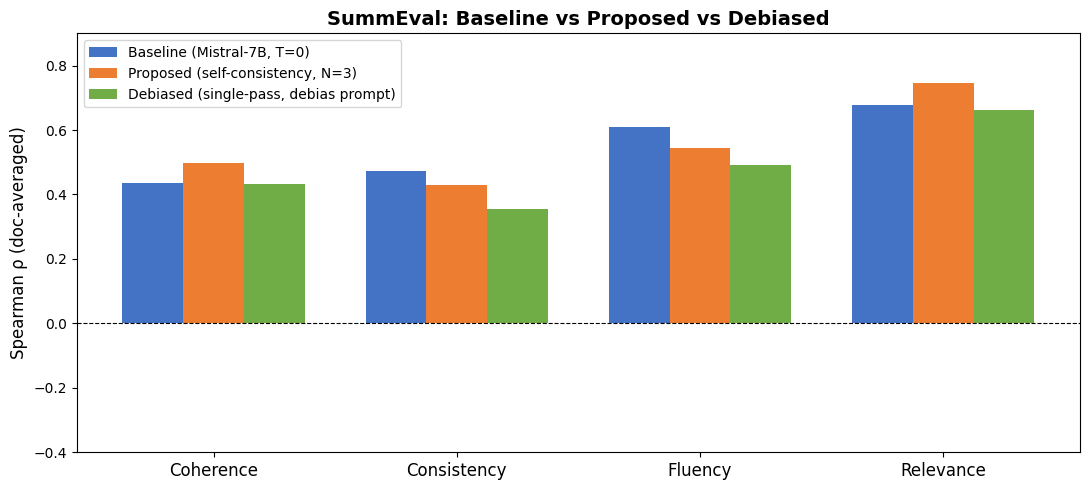

Saved: comparison_bar_chart.png


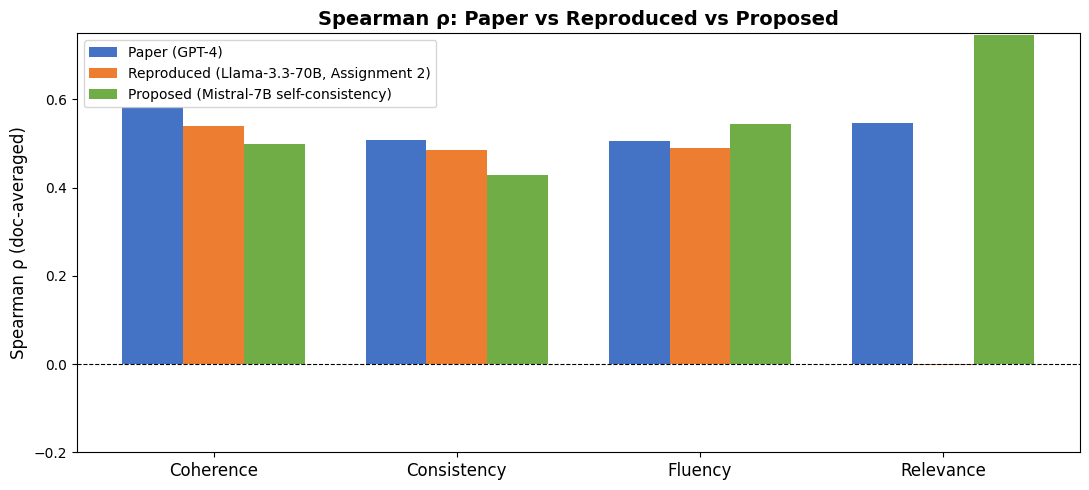

Saved: paper_vs_reproduced_vs_proposed.png


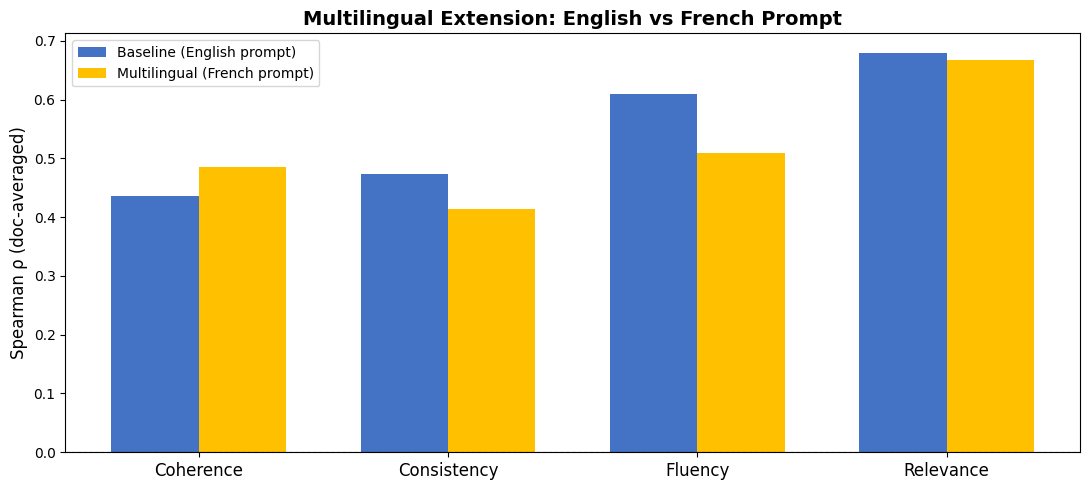

Saved: multilingual_comparison.png


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ── Chart 1: Baseline vs Proposed vs Debiased ────────────────────────────────
se = [r for r in compare_rows if r['Dataset'] == 'summeval']
if se:
    dims   = [r['Dimension'].capitalize() for r in se]
    base_r = [r['Baseline ρ'] for r in se]
    prop_r = [r['Proposed ρ'] for r in se]
    deb_r  = [r['Debiased ρ'] for r in se]

    x, w = np.arange(len(dims)), 0.25
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x - w, base_r, w, label='Baseline (Mistral-7B, T=0)',                         color='#4472C4')
    ax.bar(x,     prop_r, w, label=f'Proposed (self-consistency, N={SELF_CONSISTENCY_N})', color='#ED7D31')
    ax.bar(x + w, deb_r,  w, label='Debiased (single-pass, debias prompt)',               color='#70AD47')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x); ax.set_xticklabels(dims, fontsize=12)
    ax.set_ylabel('Spearman ρ (doc-averaged)', fontsize=12)
    ax.set_title('SummEval: Baseline vs Proposed vs Debiased', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10); ax.set_ylim(-0.4, 0.9)
    plt.tight_layout()
    plt.savefig('Assignment3/outputs/comparison_bar_chart.png', dpi=200)
    plt.show(); print('Saved: comparison_bar_chart.png')

# ── Chart 2: Paper vs Reproduced vs Proposed ─────────────────────────────────
paper_rho  = {'Coherence': 0.582, 'Consistency': 0.507, 'Fluency': 0.506, 'Relevance': 0.547}
reprod_rho = {'Coherence': 0.541, 'Consistency': 0.485, 'Fluency': 0.489, 'Relevance': -0.002}
proposed_rho = {r['Dimension'].capitalize(): r['Proposed ρ'] for r in se}

dims2 = list(paper_rho.keys())
x2, w2 = np.arange(len(dims2)), 0.25
fig2, ax2 = plt.subplots(figsize=(11, 5))
ax2.bar(x2 - w2, [paper_rho[d]         for d in dims2], w2, label='Paper (GPT-4)',                               color='#4472C4')
ax2.bar(x2,      [reprod_rho[d]        for d in dims2], w2, label='Reproduced (Llama-3.3-70B, Assignment 2)',    color='#ED7D31')
ax2.bar(x2 + w2, [proposed_rho.get(d,0) for d in dims2], w2, label='Proposed (Mistral-7B self-consistency)',   color='#70AD47')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(x2); ax2.set_xticklabels(dims2, fontsize=12)
ax2.set_ylabel('Spearman ρ (doc-averaged)', fontsize=12)
ax2.set_title('Spearman ρ: Paper vs Reproduced vs Proposed', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10); ax2.set_ylim(-0.2, 0.75)
plt.tight_layout()
plt.savefig('Assignment3/outputs/paper_vs_reproduced_vs_proposed.png', dpi=200)
plt.show(); print('Saved: paper_vs_reproduced_vs_proposed.png')

# ── Chart 3: Multilingual (French vs English baseline) ───────────────────────
ml_runs = [r for r in metrics['runs']
           if r['dataset'] == 'summeval' and 'multilingual' in r.get('variant', '')]
if ml_runs:
    ml_dims  = [r['dimension'].capitalize() for r in ml_runs]
    ml_rho   = [round(r['correlation']['spearman'], 4) for r in ml_runs]
    base_map = {r['Dimension'].capitalize(): r['Baseline ρ'] for r in se}
    base_ml  = [base_map.get(d, 0) for d in ml_dims]

    x3, w3 = np.arange(len(ml_dims)), 0.35
    fig3, ax3 = plt.subplots(figsize=(11, 5))
    ax3.bar(x3 - w3/2, base_ml, w3, label='Baseline (English prompt)', color='#4472C4')
    ax3.bar(x3 + w3/2, ml_rho,  w3, label='Multilingual (French prompt)', color='#FFC000')
    ax3.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax3.set_xticks(x3); ax3.set_xticklabels(ml_dims, fontsize=12)
    ax3.set_ylabel('Spearman ρ (doc-averaged)', fontsize=12)
    ax3.set_title('Multilingual Extension: English vs French Prompt', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('Assignment3/outputs/multilingual_comparison.png', dpi=200)
    plt.show(); print('Saved: multilingual_comparison.png')
else:
    print('No multilingual runs in results.')

## Cell 9 — Scatter & Histogram Plots

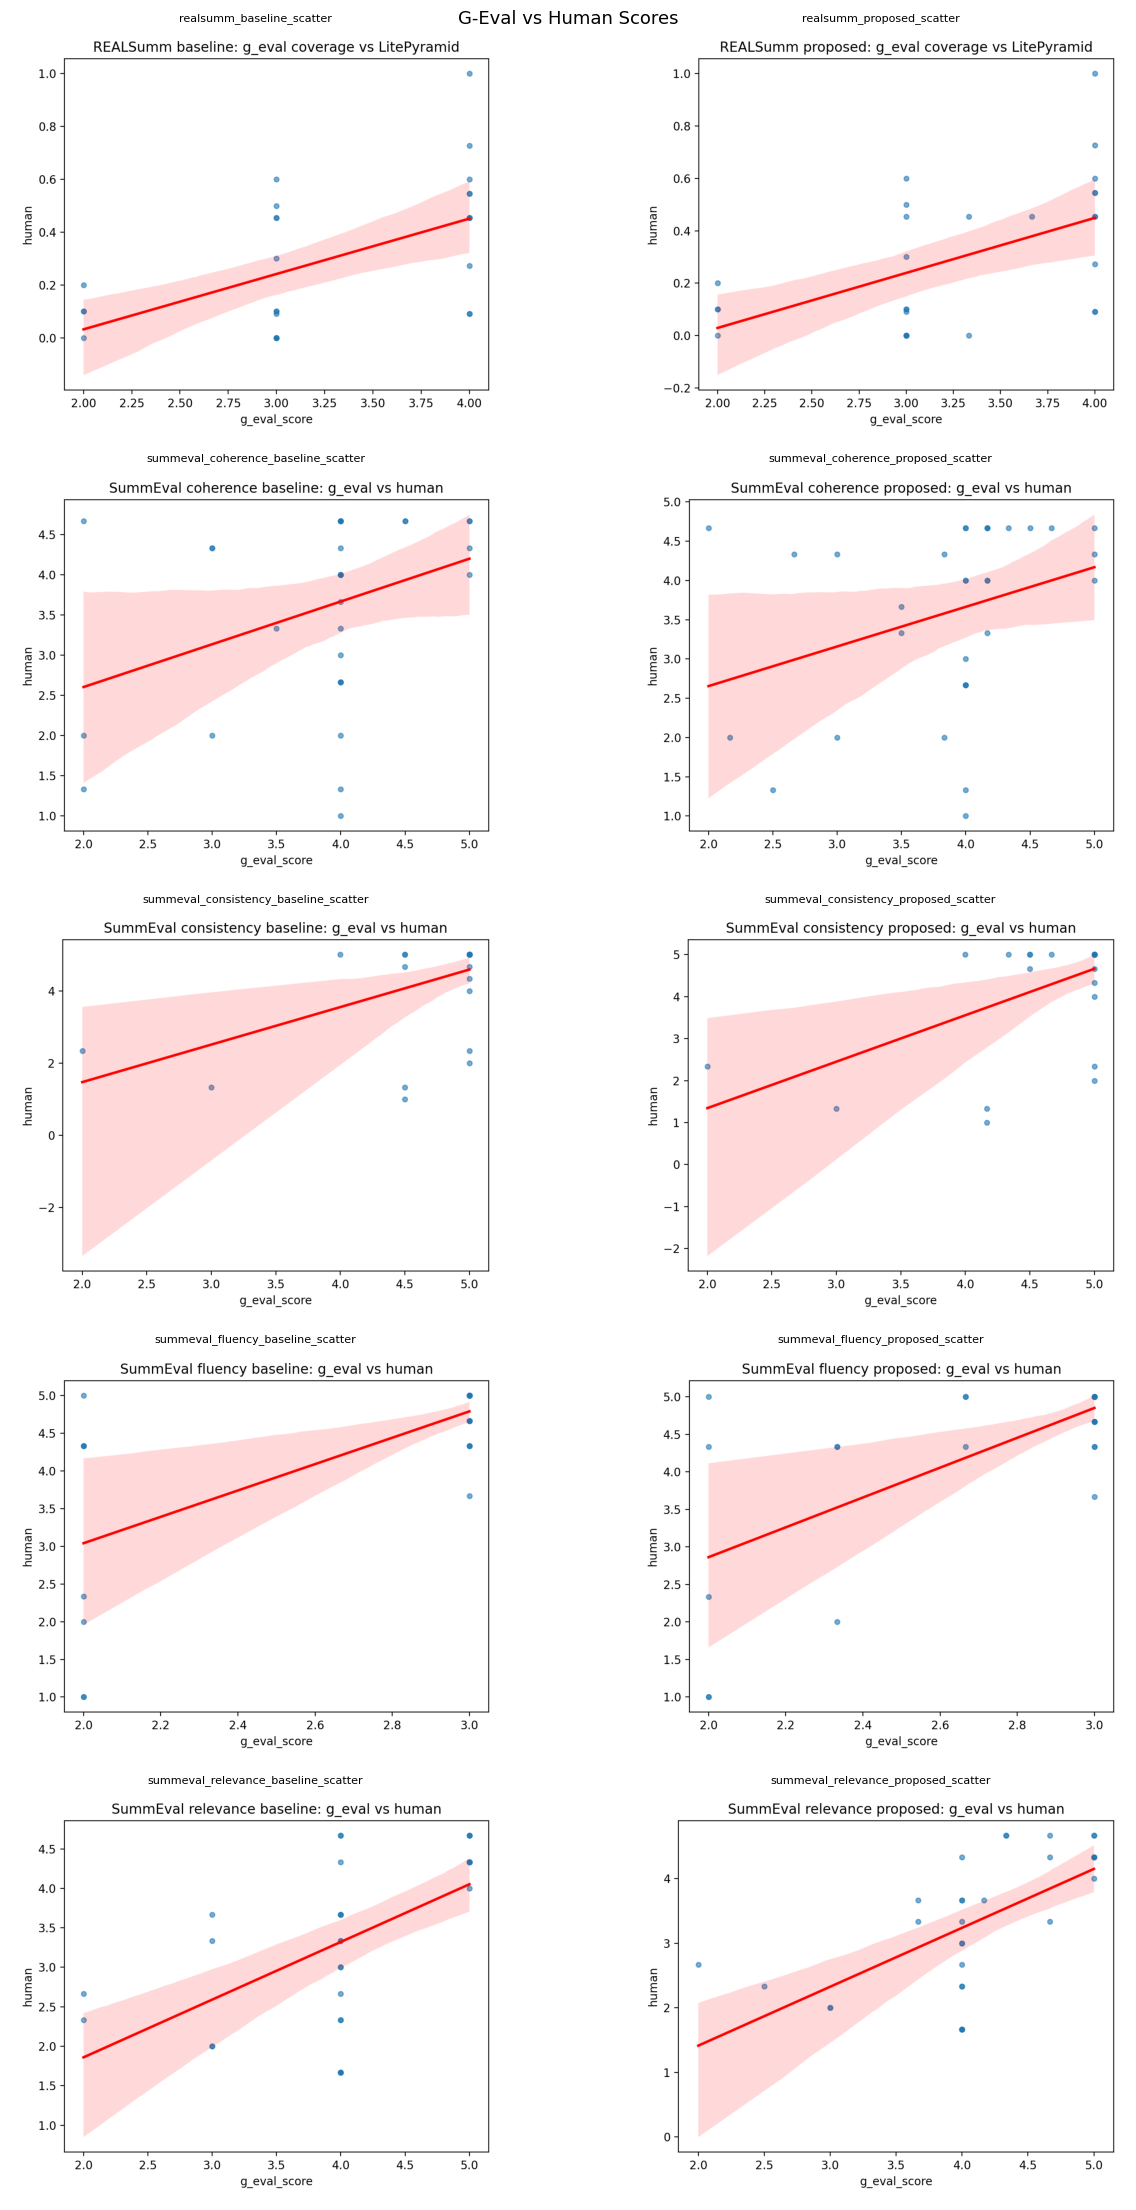

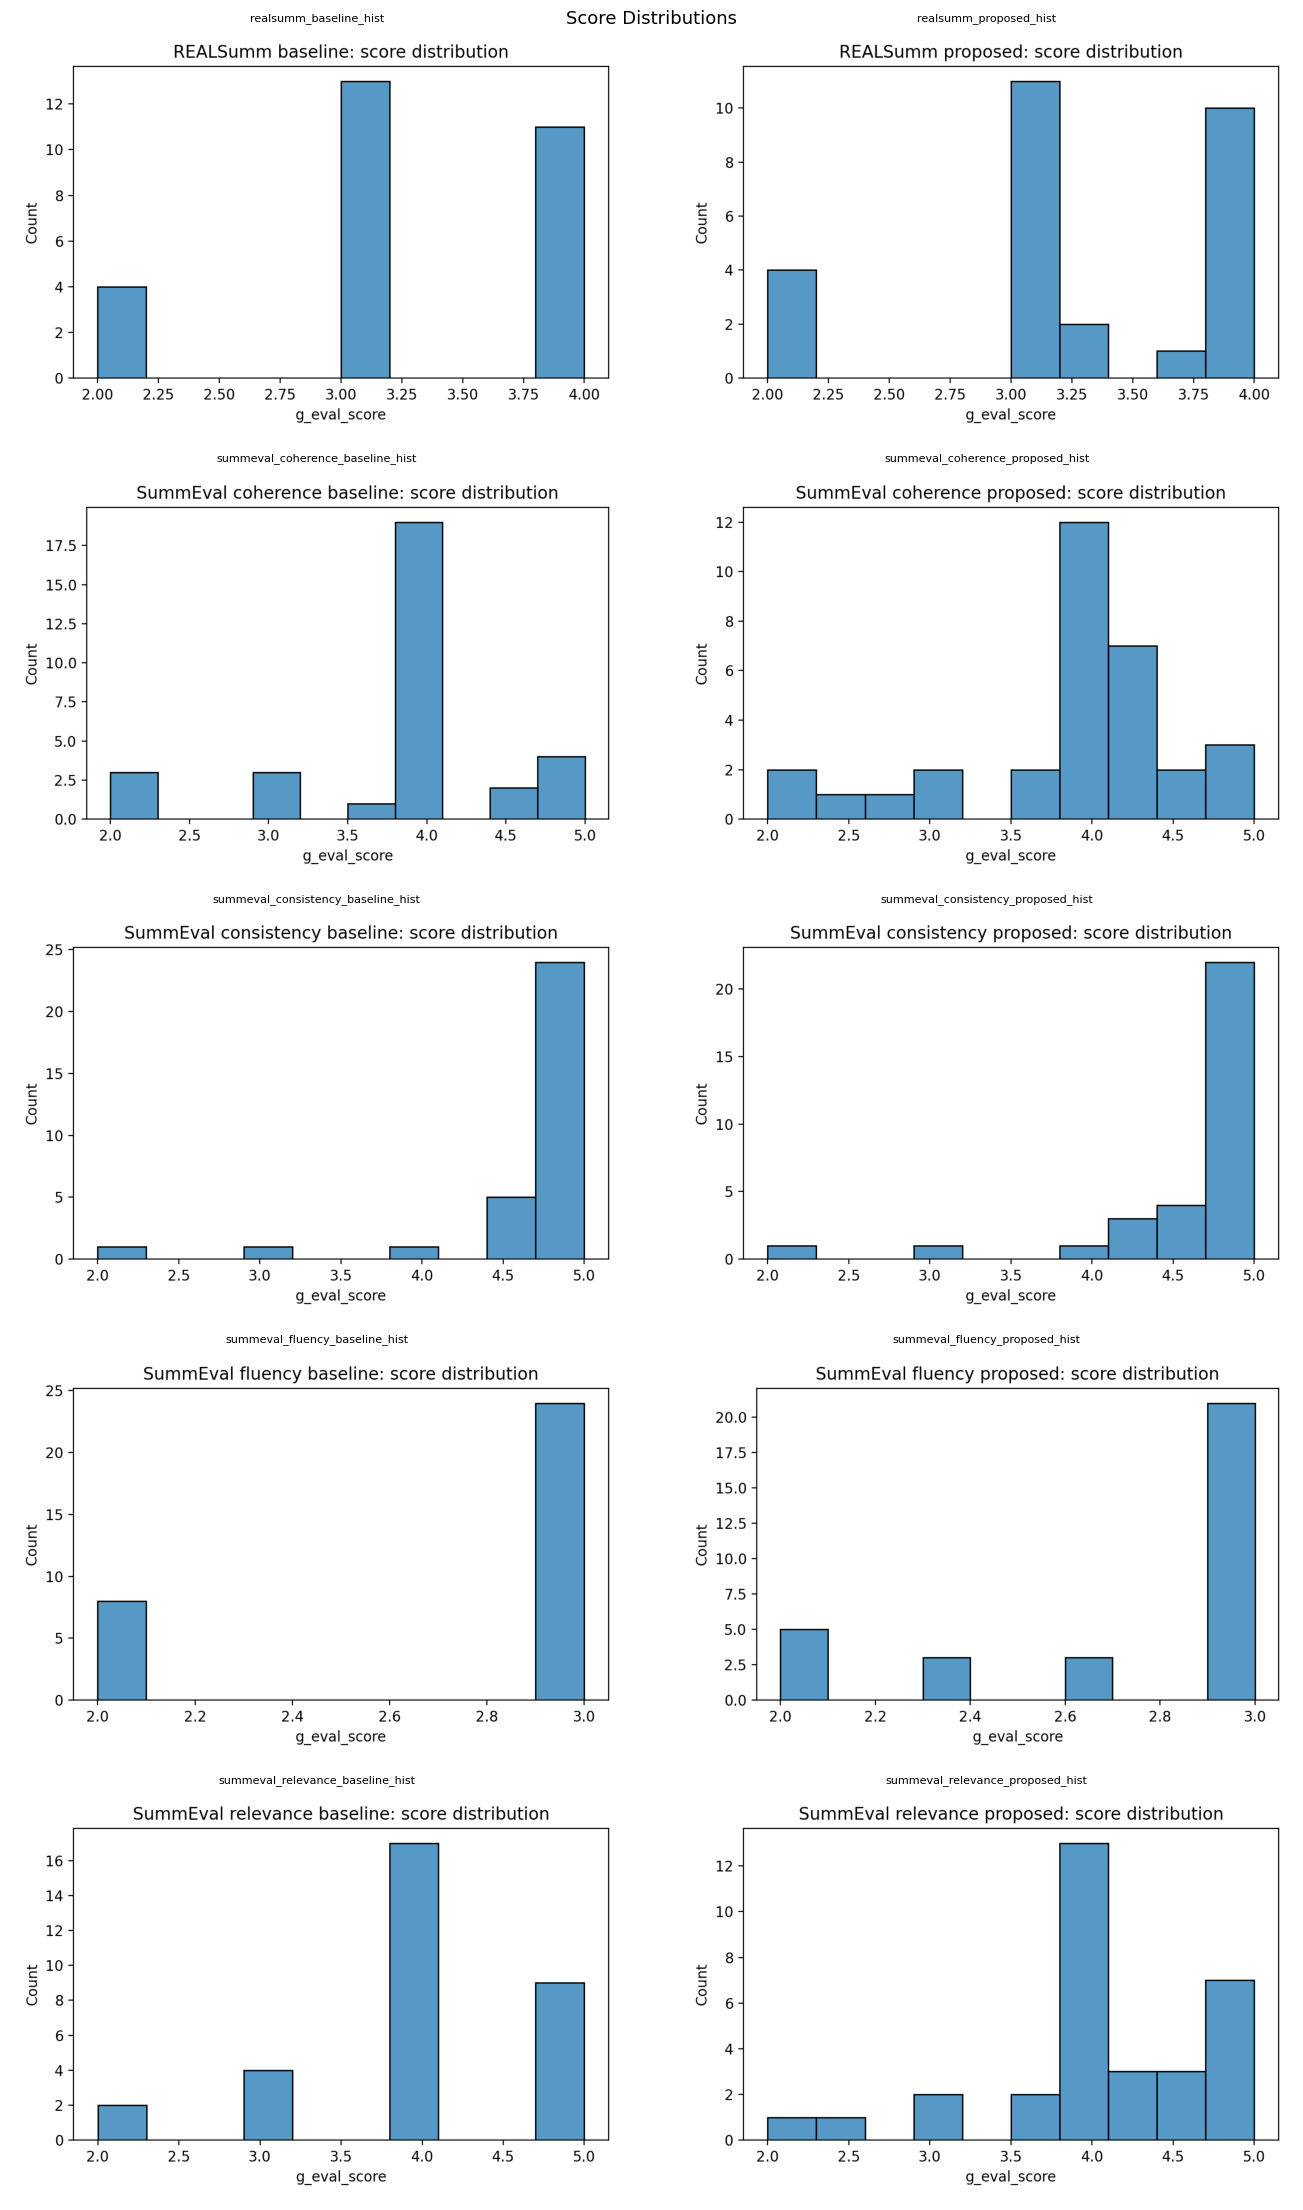

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

def show_plots(pattern, title):
    plots = sorted(glob.glob(pattern))
    if not plots:
        print(f'No plots found: {pattern}'); return
    cols = 2
    rows_n = (len(plots) + cols - 1) // cols
    fig, axes = plt.subplots(rows_n, cols, figsize=(14, 4.5 * rows_n))
    axes = axes.flatten()
    for ax, fp in zip(axes, plots):
        ax.imshow(mpimg.imread(fp)); ax.axis('off')
        ax.set_title(fp.split('/')[-1].replace('plot_','').replace('.png',''), fontsize=8)
    for ax in axes[len(plots):]: ax.axis('off')
    plt.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()

show_plots('Assignment3/outputs/plot_*_scatter.png', 'G-Eval vs Human Scores')
show_plots('Assignment3/outputs/plot_*_hist.png',    'Score Distributions')

## Cell 10 — Statistical Significance

In [11]:
print('Wilcoxon Signed-Rank Test: Proposed vs Baseline\n')
header = f'{"Dataset":<12}{"Dimension":<24}{"MAE Baseline":<16}{"MAE Proposed":<16}{"p-value":<12}Verdict'
print(header)
print('-' * len(header))
for run in metrics['runs']:
    if run.get('variant') != 'proposed':
        continue
    sig = run.get('significance_vs_baseline', {})
    print(
        f"{run['dataset']:<12}"
        f"{run['dimension']:<24}"
        f"{str(sig.get('mean_error_baseline','-')):<16}"
        f"{str(sig.get('mean_error_proposed','-')):<16}"
        f"{str(sig.get('p_value','-')):<12}"
        f"{sig.get('verdict','-')}"
    )

Wilcoxon Signed-Rank Test: Proposed vs Baseline

Dataset     Dimension               MAE Baseline    MAE Proposed    p-value     Verdict
---------------------------------------------------------------------------------------
summeval    coherence               0.849           0.8698          0.7365      not significant (p=0.737); proposed may still be directionally better
summeval    consistency             0.5781          0.5885          0.6473      not significant (p=0.647); proposed may still be directionally better
summeval    fluency                 1.7292          1.75            0.7057      not significant (p=0.706); proposed may still be directionally better
summeval    relevance               0.9167          0.875           0.0941      not significant (p=0.094); proposed may still be directionally better
realsumm    litepyramid_recall      2.9558          2.9677          0.7181      not significant (p=0.718); proposed may still be directionally better


## Cell 11 — Multilingual Results

In [12]:
print('Multilingual Prompt Extension (French vs English Baseline)\n')
ml_runs = [r for r in metrics['runs'] if 'multilingual' in r.get('variant', '')]
if not ml_runs:
    print('No multilingual runs found.')
else:
    base_lookup = {(r['dataset'], r['dimension']): r['correlation']['spearman']
                   for r in metrics['runs'] if r.get('variant') == 'baseline'}
    print(f'{"Dataset":<12}{"Dimension":<24}{"Baseline (EN) ρ":<18}{"French ρ":<18}Delta')
    print('-' * 80)
    for run in ml_runs:
        key = (run['dataset'], run['dimension'])
        base_rho = base_lookup.get(key, 0)
        ml_rho   = run['correlation']['spearman']
        print(f"{run['dataset']:<12}{run['dimension']:<24}{base_rho:<18.4f}{ml_rho:<18.4f}{ml_rho-base_rho:+.4f}")

Multilingual Prompt Extension (French vs English Baseline)

Dataset     Dimension               Baseline (EN) ρ   French ρ          Delta
--------------------------------------------------------------------------------
summeval    coherence               0.4363            0.4855            +0.0491
summeval    consistency             0.4727            0.4142            -0.0585
summeval    fluency                 0.6092            0.5098            -0.0994
summeval    relevance               0.6788            0.6669            -0.0118
realsumm    litepyramid_recall      0.3176            0.3590            +0.0414


## Cell 12 — Output Files

In [13]:
import glob
outputs = sorted(glob.glob('Assignment3/outputs/*'))
print(f'{len(outputs)} output files:\n')
for fp in outputs:
    print(f"  {os.path.getsize(fp)/1024:7.1f} KB   {fp}")

45 output files:

     91.3 KB   Assignment3/outputs/comparison_bar_chart.png
     75.8 KB   Assignment3/outputs/multilingual_comparison.png
      0.0 KB   Assignment3/outputs/multilingual_dataset_summary.json
     89.7 KB   Assignment3/outputs/paper_vs_reproduced_vs_proposed.png
     36.3 KB   Assignment3/outputs/plot_realsumm_baseline_hist.png
     65.9 KB   Assignment3/outputs/plot_realsumm_baseline_scatter.png
     35.2 KB   Assignment3/outputs/plot_realsumm_proposed_hist.png
     69.0 KB   Assignment3/outputs/plot_realsumm_proposed_scatter.png
     40.4 KB   Assignment3/outputs/plot_summeval_coherence_baseline_hist.png
     62.5 KB   Assignment3/outputs/plot_summeval_coherence_baseline_scatter.png
     35.3 KB   Assignment3/outputs/plot_summeval_coherence_proposed_hist.png
     63.3 KB   Assignment3/outputs/plot_summeval_coherence_proposed_scatter.png
     36.6 KB   Assignment3/outputs/plot_summeval_consistency_baseline_hist.png
     56.6 KB   Assignment3/outputs/plot_summeval_con

## Cell 13 — Download Outputs

In [16]:
import shutil
from google.colab import files

shutil.make_archive('/content/assignment3_outputs', 'zip', 'Assignment3/outputs')
files.download('/content/assignment3_outputs.zip')
print('Download started.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
